In [ ]:
import os
import csv
import random
import time
from pathlib import Path

import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models


CONFIG = 
{
    "img_dir": "images",
    "ann_dir": "annotations",
    "models": ["resnet50", "efficientnet_v2_s"],  # will train each
    "num_classes": 8,
    "batch_size": 32,
    "num_epochs": 20,
    "lr": 2e-4,
    "weight_decay": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "num_workers": 0,  # use 0 on Windows
    "mix_alpha": 1.0,  # MixUp/CutMix strength
    "use_cutmix": True,
    "use_focal": False,  # set True to use focal loss instead of label smoothing CE
    "label_smoothing": 0.1,
    "early_stopping_patience": 4,
    "save_dir": "checkpoints",
    "log_csv": "training_log.csv",
    "tta_transforms": 3,  # number of TTA augmentations to average at inference
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)

class AffectDataset(Dataset):

    def __init__(self, img_dir, ann_dir, ids, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.ids = ids
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        _id = self.ids[idx]
        img_path = os.path.join(self.img_dir, f"{_id}.jpg")
        img = Image.open(img_path).convert("RGB")
        exp = int(np.load(os.path.join(self.ann_dir, f"{_id}_exp.npy")).item())
        val = float(np.load(os.path.join(self.ann_dir, f"{_id}_val.npy")).item())
        aro = float(np.load(os.path.join(self.ann_dir, f"{_id}_aro.npy")).item())

        if self.transform:
            img = self.transform(img)
        else:
            img = T.ToTensor()(img)

        return {"image": img, "expression": torch.tensor(exp, dtype=torch.long),
                "va": torch.tensor([val, aro], dtype=torch.float32)}

def create_backbone(name):
    if name == "resnet50":
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        return backbone, feat_dim

    if name == "efficientnet_v2_s":
        backbone = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        feat_dim = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        return backbone, feat_dim

    raise ValueError(f"Unknown backbone {name}")

class MultiTaskHeadModel(nn.Module):
    def __init__(self, backbone_name, num_classes=8, dropout=0.3):
        super().__init__()
        backbone, feat_dim = create_backbone(backbone_name)
        self.base = backbone
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        self.exp_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
        self.va_head = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        feats = self.base(x)  # (B, feat_dim)
        proj = self.proj(feats)
        exp_logits = self.exp_head(proj)
        va = self.va_head(proj)  # (B,2)
        return exp_logits, va

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=1.0, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = self.alpha * (1 - pt) ** self.gamma * ce
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

class DWABalancer:
    def __init__(self, num_tasks=2, T=2.0):
        self.num_tasks = num_tasks
        self.T = T
        self.history = [[] for _ in range(num_tasks)]

    def update(self, losses):
        for i, l in enumerate(losses):
            self.history[i].append(l)

    def weights(self):
        if len(self.history[0]) < 2:
            return [1.0] * self.num_tasks
        ratios = []
        for h in self.history:
            ratios.append(h[-1] / (h[-2] + 1e-8))
        ratios = torch.tensor(ratios, dtype=torch.float32)
        w = torch.exp(ratios / self.T)
        w = (self.num_tasks * w / w.sum()).tolist()
        return w

def mixup_data(x, y_cls, y_va, alpha=1.0):
    if alpha <= 0:
        return x, y_cls, y_cls, y_va, y_va, 1.0
    lam = np.random.beta(alpha, alpha)
    B = x.size(0)
    idx = torch.randperm(B).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
        return mixed_x, y_cls, y_cls[idx], y_va, y_va[idx], lam

def cutmix_data(x, y_cls, y_va, alpha=1.0):
    if alpha <= 0:
        return x, y_cls, y_cls, y_va, y_va, 1.0
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = x.size()
    idx = torch.randperm(B).to(x.device)
    rx = np.random.randint(W)
    ry = np.random.randint(H)
    rw = int(W * np.sqrt(1 - lam))
    rh = int(H * np.sqrt(1 - lam))
    x1 = np.clip(rx - rw // 2, 0, W); x2 = np.clip(rx + rw // 2, 0, W)
    y1 = np.clip(ry - rh // 2, 0, H); y2 = np.clip(ry + rh // 2, 0, H)
   
    x1, x2 = int(x1), int(x2)
    y1, y2 = int(y1), int(y2)
    if x2 > x1 and y2 > y1:
        x[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H) + 1e-12)
    return x, y_cls, y_cls[idx], y_va, y_va[idx], lam

def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

def tta_predict(model, pil_img, device, tta_count=4):
    model.eval()
    ttfms = [
        T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
        T.Compose([T.Resize((224,224)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
        T.Compose([T.Resize((224,224)), T.RandomRotation(10), T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    ]

    exp_logits_list, va_list = [], []
    with torch.no_grad():
        for i in range(tta_count):
            tfm = random.choice(ttfms)
            x = tfm(pil_img).unsqueeze(0).to(device)
            exp_logits, va = model(x)
            exp_logits_list.append(F.softmax(exp_logits, dim=1))
            va_list.append(va)
    exp_final = torch.mean(torch.stack(exp_logits_list), dim=0)
    va_final = torch.mean(torch.stack(va_list), dim=0)
    return exp_final, va_final

def append_csv_row(csv_path, row, header=None):
    write_header = not os.path.exists(csv_path)
    with open(csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header and header:
            writer.writerow(header)
        writer.writerow(row)

def train_one_model(model_name, config):
    device = torch.device(config["device"])
    img_dir = config["img_dir"]; ann_dir = config["ann_dir"]
    print(f"\n\n=== TRAIN {model_name} on device {device} ===")

   
    all_ids = sorted([int(f.split("_")[0]) for f in os.listdir(ann_dir) if f.endswith("_exp.npy")])
    train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=42, shuffle=True)

    train_labels = [int(np.load(os.path.join(ann_dir, f"{i}_exp.npy")).item()) for i in train_ids]
    class_counts = np.bincount(train_labels, minlength=config["num_classes"])
    
    class_weights_for_sampler = 1.0 / (class_counts + 1e-6)
    sample_weights = [class_weights_for_sampler[l] for l in train_labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    
    train_tfms = T.Compose([
        T.RandomResizedCrop(224, scale=(0.7,1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomApply([T.RandomAffine(degrees=15, translate=(0.1,0.1), shear=8)], p=0.5),
        T.ColorJitter(0.3,0.3,0.3,0.05),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        T.RandomErasing(p=0.25),
    ])
    val_tfms = T.Compose([
        T.Resize((224,224)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    train_ds = AffectDataset(img_dir, ann_dir, train_ids, transform=train_tfms)
    val_ds = AffectDataset(img_dir, ann_dir, val_ids, transform=val_tfms)

    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], sampler=sampler,
                              num_workers=config["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"], shuffle=False,
                            num_workers=config["num_workers"], pin_memory=True)
    dataloaders = {"train": train_loader, "val": val_loader}

    # model
    model = MultiTaskHeadModel(model_name, num_classes=config["num_classes"]).to(device)

    # optimizer / scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    # losses
    if config["use_focal"]:
        cls_criterion = FocalLoss(gamma=2.0)
    else:
        cls_criterion = nn.CrossEntropyLoss(label_smoothing=config["label_smoothing"])
    reg_criterion = nn.MSELoss()

    # DWA balancer
    balancer = DWABalancer(num_tasks=2, T=2.0)

    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_val_loss = float("inf")
    best_epoch = -1
    patience_counter = 0
    csv_header = ["model", "epoch", "phase", "loss", "acc", "valence_rmse", "valence_corr_mean"]
    csv_path = os.path.join(config["save_dir"], f"{model_name}_log.csv")

    for epoch in range(1, config["num_epochs"] + 1):
        print(f"\nEpoch {epoch}/{config['num_epochs']}")
        epoch_start = time.time()

        for phase in ["train", "val"]:
            is_train = phase == "train"
            model.train() if is_train else model.eval()

            running_loss = 0.0
            running_corrects = 0
            running_samples = 0

            # simple trackers for valence corr etc (use numpy)
            all_val_preds = []
            all_val_targets = []

            for batch in dataloaders[phase]:
                imgs = batch["image"].to(device, non_blocking=True)
                labels = batch["expression"].to(device, non_blocking=True)
                va = batch["va"].to(device, non_blocking=True)  # (B,2)

                # MixUp/CutMix augmentation (train only)
                if is_train and random.random() < 0.5:
                    if config["use_cutmix"] and random.random() < 0.5:
                        imgs, la, lb, va_a, va_b, lam = cutmix_data(imgs, labels, va, alpha=config["mix_alpha"])
                    else:
                        imgs, la, lb, va_a, va_b, lam = mixup_data(imgs, labels, va, alpha=config["mix_alpha"])
                else:
                    la, lb = labels, labels
                    va_a, va_b = va, va
                    lam = 1.0

                optimizer.zero_grad()
                with torch.set_grad_enabled(is_train):
                    with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                        exp_logits, va_pred = model(imgs)  
                        
                        loss_cls = lam * cls_criterion(exp_logits, la) + (1 - lam) * cls_criterion(exp_logits, lb)
                       
                        loss_reg = lam * reg_criterion(va_pred, va_a) + (1 - lam) * reg_criterion(va_pred, va_b)

                      
                        weights = balancer.weights()
                        loss = weights[0] * loss_cls + weights[1] * loss_reg

                    if is_train:
                        scaler.scale(loss).backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * imgs.size(0)
                running_samples += imgs.size(0)
                
                preds = exp_logits.argmax(dim=1)
                running_corrects += (preds == labels).sum().item()

              
                all_val_preds.append(va_pred.detach().cpu().numpy())
                all_val_targets.append(va.detach().cpu().numpy())

               
                balancer.update([loss_cls.item(), loss_reg.item()])

            epoch_loss = running_loss / running_samples
            epoch_acc = running_corrects / running_samples

            
            all_val_preds = np.concatenate(all_val_preds, axis=0)
            all_val_targets = np.concatenate(all_val_targets, axis=0)
            
            valence_rmse = float(np.sqrt(np.mean((all_val_preds[:,0] - all_val_targets[:,0])**2)))
            
            try:
                valence_corr = float(np.corrcoef(all_val_preds[:,0], all_val_targets[:,0])[0,1])
                if np.isnan(valence_corr):
                    valence_corr = 0.0
            except Exception:
                valence_corr = 0.0

            print(f"{phase.upper()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} ValenceRMSE: {valence_rmse:.4f} ValenceCorr: {valence_corr:.4f}")

            # log per-phase
            append_csv_row(csv_path, [model_name, epoch, phase, epoch_loss, epoch_acc, valence_rmse, valence_corr], header=csv_header)

            # scheduler step on validation loss & checkpoint
            if phase == "val":
                scheduler.step(epoch_loss)
                for param_group in optimizer.param_groups:
                    # print LR for debugging (no verbose arg compat issues)
                    print(f"LR: {param_group['lr']:.6e}")
                # checkpoint if improved
                if epoch_loss < best_val_loss - 1e-6:
                    best_val_loss = epoch_loss
                    best_epoch = epoch
                    patience_counter = 0
                    ckpt_path = os.path.join(config["save_dir"], f"{model_name}_best.pth")
                    torch.save(model.state_dict(), ckpt_path)
                    print(f"Saved best model -> {ckpt_path}")
                else:
                    patience_counter += 1

        epoch_time = time.time() - epoch_start
        print(f"Epoch time: {epoch_time:.1f}s, best_val_loss: {best_val_loss:.4f}, patience: {patience_counter}/{config['early_stopping_patience']}")

        if patience_counter >= config["early_stopping_patience"]:
            print("Early stopping triggered.")
            break

    # end epochs
    print(f"Finished training {model_name}. Best epoch: {best_epoch}, best val loss: {best_val_loss:.4f}")
    return os.path.join(config["save_dir"], f"{model_name}_best.pth"), best_val_loss


if __name__ == "__main__":
    cfg = CONFIG.copy()
    if not os.path.isdir(cfg["img_dir"]) or not os.path.isdir(cfg["ann_dir"]):
        raise RuntimeError("Set correct img_dir and ann_dir in CONFIG at top of script.")

    results = {}
    for m in cfg["models"]:
        ckpt, loss = train_one_model(m, cfg)
        results[m] = {"ckpt": ckpt, "val_loss": loss}

    print("\nAll training finished. Models and best val losses:")
    for k,v in results.items():
        print(k, v)




=== TRAIN resnet50 on device cpu ===
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\areeb/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:46<00:00, 2.19MB/s]
C:\Users\areeb\AppData\Local\Temp\ipykernel_11572\2268267032.py:308: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
c:\Users\areeb\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Epoch 1/20


C:\Users\areeb\AppData\Local\Temp\ipykernel_11572\2268267032.py:350: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


TRAIN Loss: 2.2091 Acc: 0.2035 ValenceRMSE: 0.4794 ValenceCorr: 0.1254
VAL Loss: 1.9885 Acc: 0.3212 ValenceRMSE: 0.4228 ValenceCorr: 0.4784
LR: 2.000000e-04
Saved best model -> checkpoints\resnet50_best.pth
Epoch time: 695.3s, best_val_loss: 1.9885, patience: 0/4

Epoch 2/20
TRAIN Loss: 2.0441 Acc: 0.3085 ValenceRMSE: 0.4493 ValenceCorr: 0.2909
VAL Loss: 1.9393 Acc: 0.3588 ValenceRMSE: 0.4196 ValenceCorr: 0.5053
LR: 2.000000e-04
Saved best model -> checkpoints\resnet50_best.pth
Epoch time: 644.8s, best_val_loss: 1.9393, patience: 0/4

Epoch 3/20
TRAIN Loss: 1.9482 Acc: 0.3445 ValenceRMSE: 0.4424 ValenceCorr: 0.3607
VAL Loss: 1.9031 Acc: 0.3925 ValenceRMSE: 0.4179 ValenceCorr: 0.4919
LR: 2.000000e-04
Saved best model -> checkpoints\resnet50_best.pth
Epoch time: 668.5s, best_val_loss: 1.9031, patience: 0/4

Epoch 4/20
TRAIN Loss: 1.8792 Acc: 0.4226 ValenceRMSE: 0.4210 ValenceCorr: 0.4585
VAL Loss: 1.8478 Acc: 0.3950 ValenceRMSE: 0.4137 ValenceCorr: 0.5131
LR: 2.000000e-04
Saved best mode

AttributeError: 'Flatten' object has no attribute 'in_features'

# Training curves

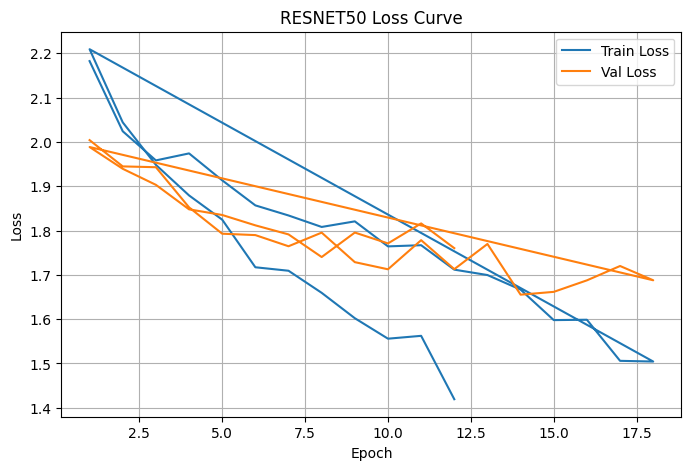

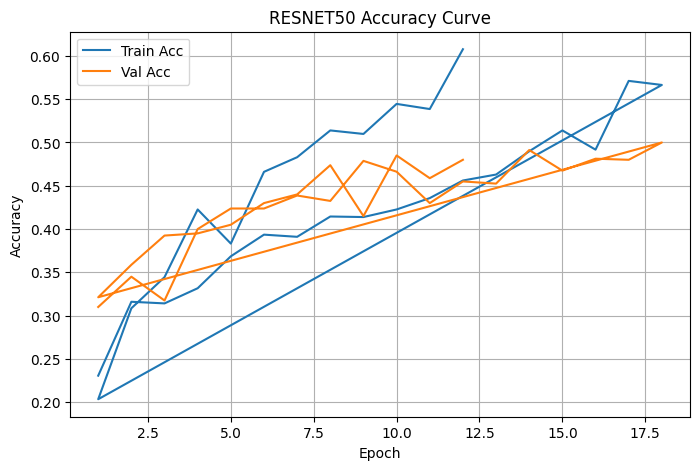

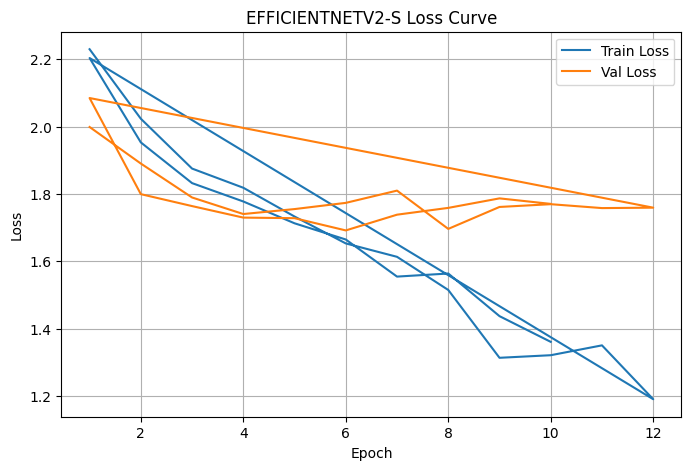

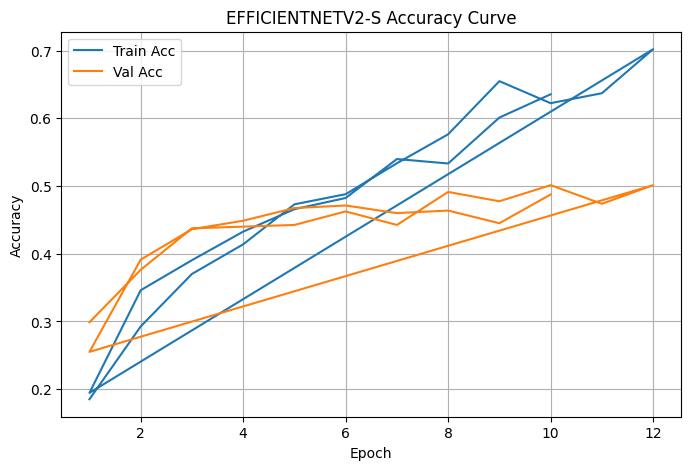

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_curves(log_csv, model_name):
   
    df = pd.read_csv(log_csv)
    
   
    train_df = df[df["phase"] == "train"]
    val_df = df[df["phase"] == "val"]

    # Plot Loss
    plt.figure(figsize=(8,5))
    plt.plot(train_df["epoch"], train_df["loss"], label="Train Loss")
    plt.plot(val_df["epoch"], val_df["loss"], label="Val Loss")
    plt.title(f"{model_name.upper()} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Accuracy
    plt.figure(figsize=(8,5))
    plt.plot(train_df["epoch"], train_df["acc"], label="Train Acc")
    plt.plot(val_df["epoch"], val_df["acc"], label="Val Acc")
    plt.title(f"{model_name.upper()} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_curves(
    "C:/Users/areeb/OneDrive/Desktop/deep/DL_Assignment1_Dataset/Dataset/Dataset/checkpoints/resnet50_log.csv",
    "ResNet50"
)

plot_training_curves(
    "C:/Users/areeb/OneDrive/Desktop/deep/DL_Assignment1_Dataset/Dataset/Dataset/checkpoints/efficientnet_v2_s_log.csv",
    "EfficientNetV2-S"
)


# Qualitative results

In [ ]:
import torch
import matplotlib.pyplot as plt

def show_qualitative_results(model, dataloader, class_names, device, num_examples=10):
    model.eval()
    correct_samples, incorrect_samples = [], []
    
    
    def denormalize(img):
        img = img.clone().permute(1, 2, 0)  
        img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        return img.clamp(0, 1)

    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device)
            labels = batch["expression"].to(device)   

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for img, label, pred in zip(images, labels, preds):
                if label == pred and len(correct_samples) < num_examples:
                    correct_samples.append((img.cpu(), label.cpu(), pred.cpu()))
                elif label != pred and len(incorrect_samples) < num_examples:
                    incorrect_samples.append((img.cpu(), label.cpu(), pred.cpu()))

            if len(correct_samples) >= num_examples and len(incorrect_samples) >= num_examples:
                break

   
    print(f"\n{num_examples} Correct Predictions:")
    fig, axes = plt.subplots(2, num_examples//2, figsize=(3*(num_examples//2), 6))
    axes = axes.flatten()
    for i, (img, label, pred) in enumerate(correct_samples):
        axes[i].imshow(denormalize(img))
        axes[i].set_title(f"GT: {class_names[label]}\nPred: {class_names[pred]}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

    
    print(f"\n {num_examples} Incorrect Predictions:")
    fig, axes = plt.subplots(2, num_examples//2, figsize=(3*(num_examples//2), 6))
    axes = axes.flatten()
    for i, (img, label, pred) in enumerate(incorrect_samples):
        axes[i].imshow(denormalize(img))
        axes[i].set_title(f"GT: {class_names[label]}\nPred: {class_names[pred]}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()



=== RESNET50 ===

✅ 10 Correct Predictions:


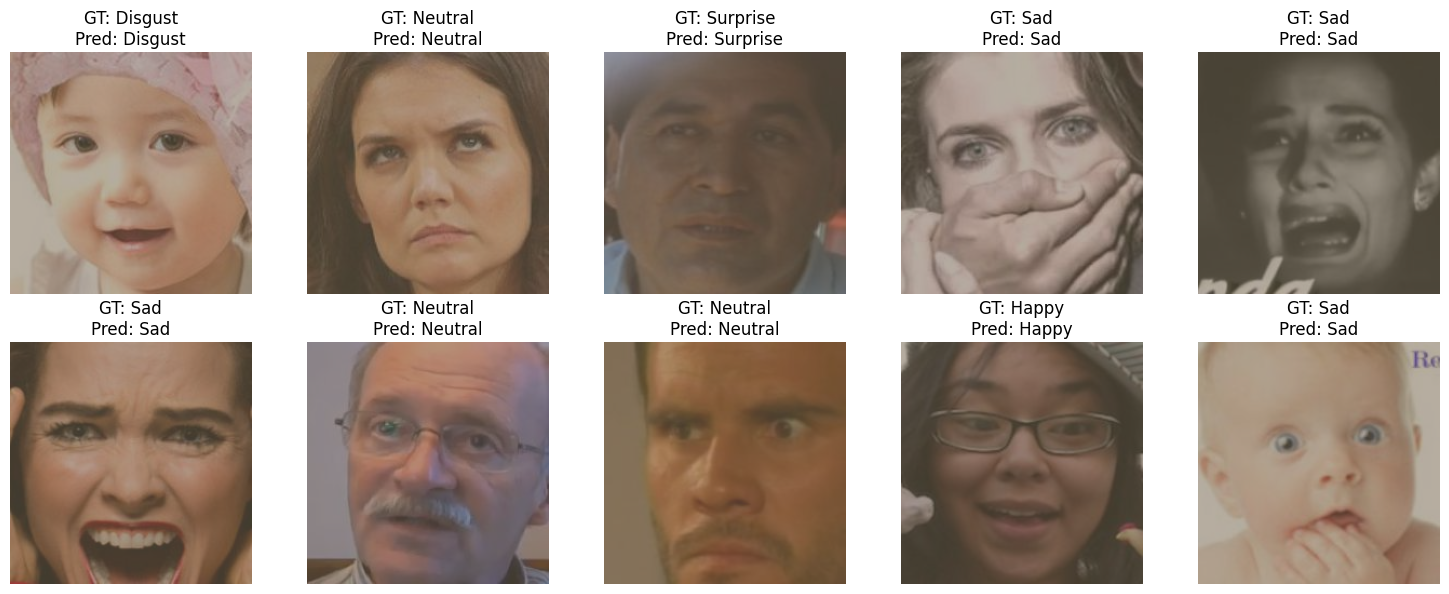


❌ 10 Incorrect Predictions:


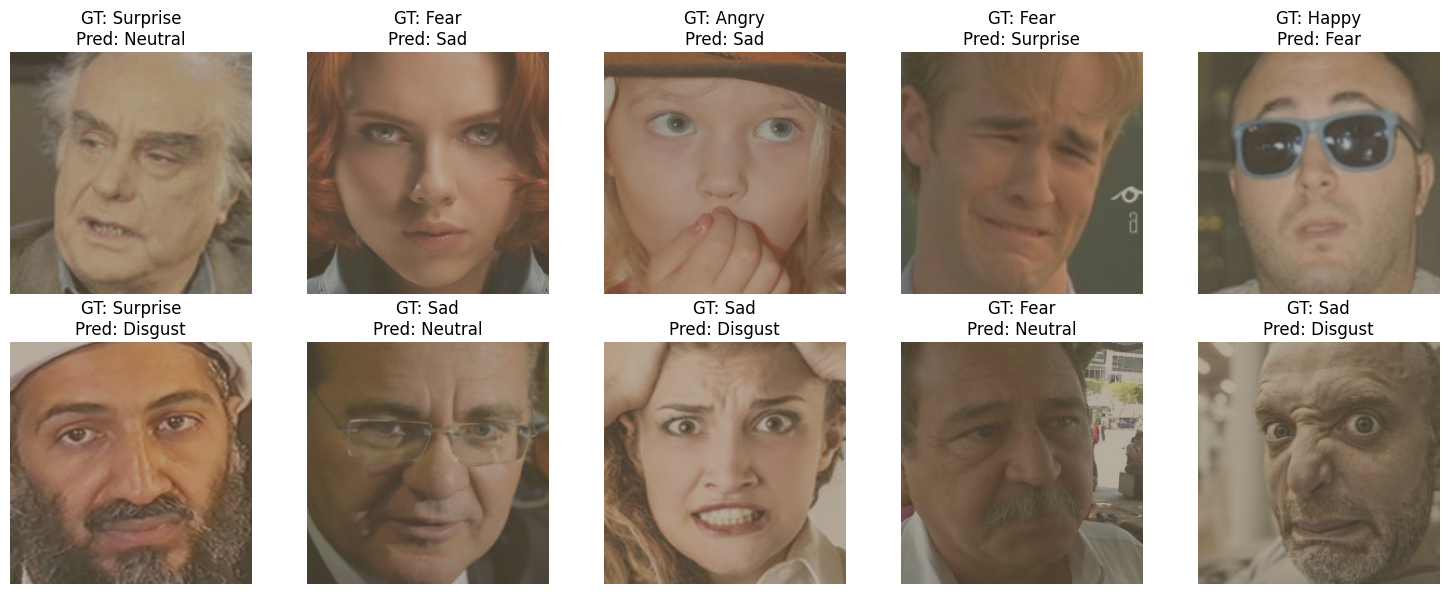


=== EfficientNetV2-S ===

✅ 10 Correct Predictions:


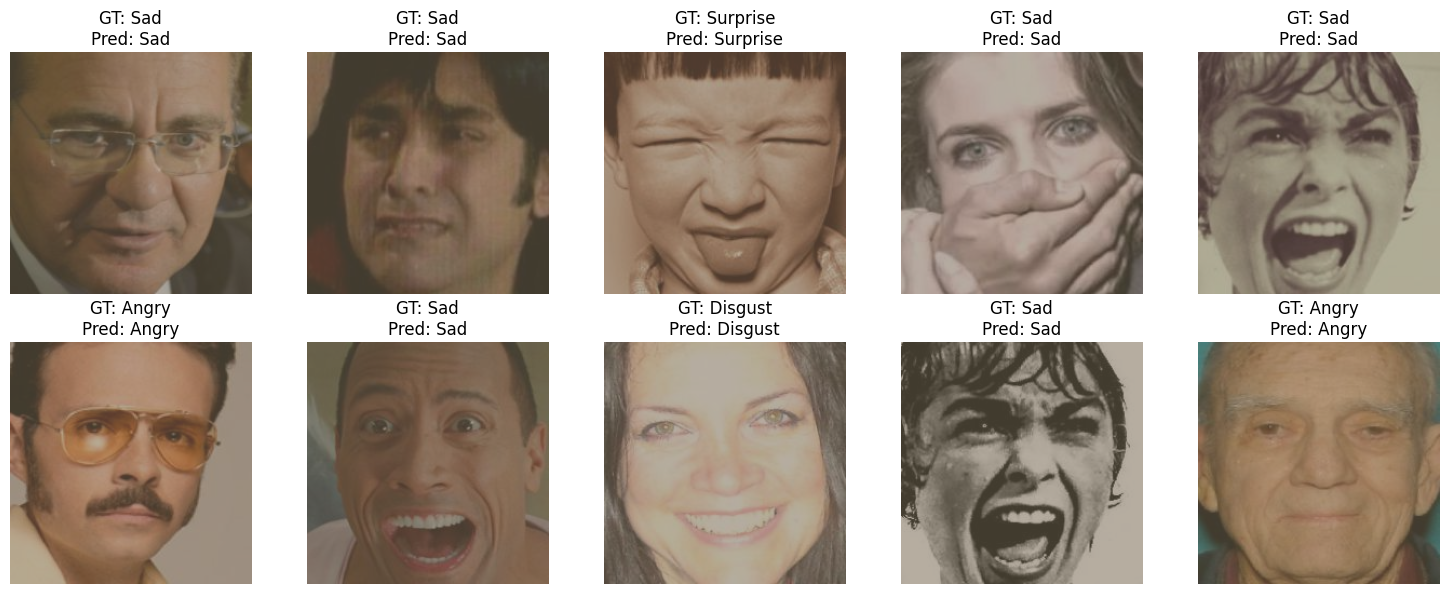


❌ 10 Incorrect Predictions:


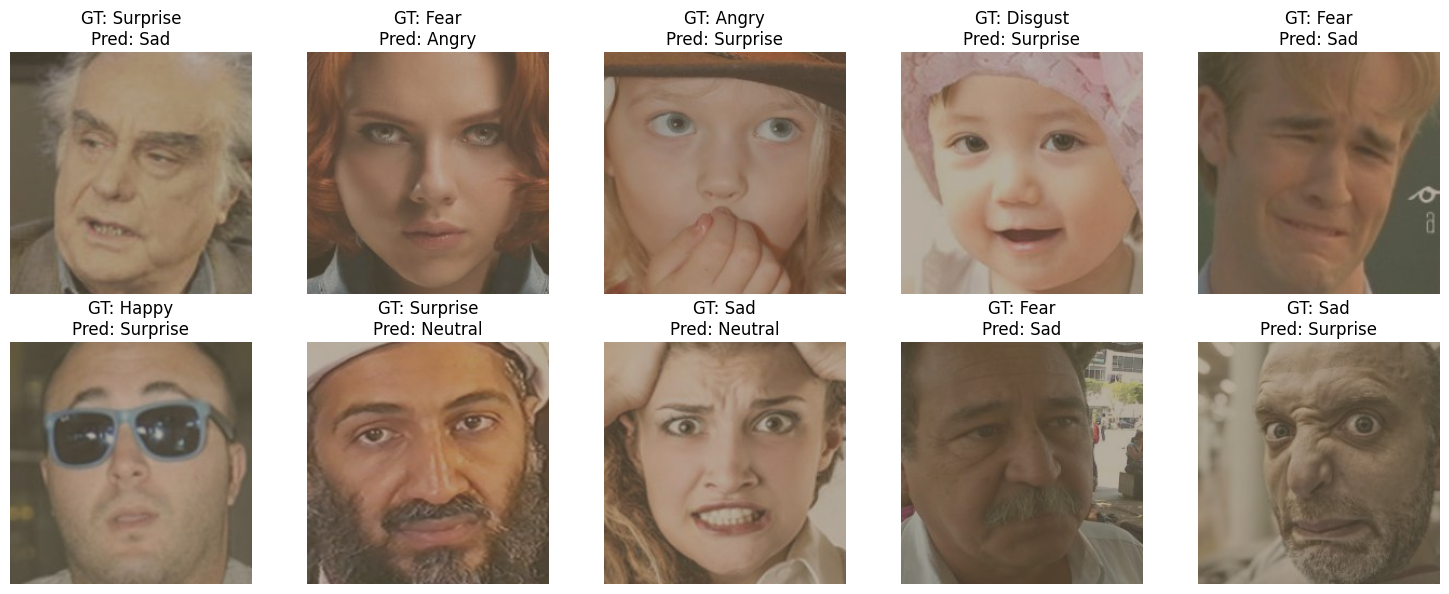

In [19]:
print("\n=== RESNET50 ===")
resnet_model = load_model(
    "C:/Users/areeb/OneDrive/Desktop/deep/DL_Assignment1_Dataset/Dataset/Dataset/checkpoints/resnet50_best.pth",
    "resnet50", num_classes, device
)
show_qualitative_results(resnet_model, val_loader, class_names, device, num_examples=10)


print("\n=== EfficientNetV2-S ===")
effnet_model = load_model(
    "C:/Users/areeb/OneDrive/Desktop/deep/DL_Assignment1_Dataset/Dataset/Dataset/checkpoints/efficientnet_v2_s_best.pth",
    "efficientnet_v2_s", num_classes, device
)
show_qualitative_results(effnet_model, val_loader, class_names, device, num_examples=10)


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
import krippendorff  # pip install krippendorff

# ---------- Categorical Metrics ----------
def evaluate_classification(model, dataloader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch["image"].to(device), batch["expression"].to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    kappa = cohen_kappa_score(y_true, y_pred)
    alpha = krippendorff.alpha(reliability_data=[y_true, y_pred], level_of_measurement="nominal")

    # AUC (one-vs-rest, macro)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except:
        auc = None
    auc_pr = average_precision_score(
        np.eye(len(np.unique(y_true)))[y_true], y_prob, average="macro"
    )

    return {
        "Accuracy": acc,
        "F1-Score": f1,
        "Cohens Kappa": kappa,
        "Krippendorfs Alpha": alpha,
        "AUC": auc,
        "AUC-PR": auc_pr,
    }


from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

def sign_agreement(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def concordance_ccc(y_true, y_pred):
    # Concordance correlation coefficient
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mean_true, mean_pred = np.mean(y_true), np.mean(y_pred)
    var_true, var_pred = np.var(y_true), np.var(y_pred)
    cov = np.cov(y_true, y_pred)[0,1]
    return (2*cov) / (var_true + var_pred + (mean_true - mean_pred)**2)

def evaluate_regression(model, dataloader, target="valence", device="cuda"):
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for batch in dataloader:
            images, labels = batch["image"].to(device), batch[target].to(device)
            outputs = model(images)
            
          
            if target == "valence":
                preds = outputs[:, -2]  # adjust depending on your head
            else:
                preds = outputs[:, -1]

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr, _ = pearsonr(y_true, y_pred)
    sagr = sign_agreement(y_true, y_pred)
    ccc = concordance_ccc(y_true, y_pred)

    return {
        "RMSE": rmse,
        "CORR": corr,
        "SAGR": sagr,
        "CCC": ccc,
    }

print("\n=== RESNET50 Categorical Metrics ===")
resnet_metrics = evaluate_classification(resnet_model, val_loader, device)
print(resnet_metrics)

print("\n=== RESNET50 Continuous Metrics (Valence) ===")
resnet_val_metrics = evaluate_regression(resnet_model, val_loader, target="valence", device=device)
print(resnet_val_metrics)

print("\n=== RESNET50 Continuous Metrics (Arousal) ===")
resnet_aro_metrics = evaluate_regression(resnet_model, val_loader, target="arousal", device=device)
print(resnet_aro_metrics)


print("\n=== EfficientNetV2-S Categorical Metrics ===")
effnet_metrics = evaluate_classification(effnet_model, val_loader, device)
print(effnet_metrics)

print("\n=== EfficientNetV2-S Continuous Metrics (Valence) ===")
effnet_val_metrics = evaluate_regression(effnet_model, val_loader, target="valence", device=device)
print(effnet_val_metrics)

print("\n=== EfficientNetV2-S Continuous Metrics (Arousal) ===")
effnet_aro_metrics = evaluate_regression(effnet_model, val_loader, target="arousal", device=device)
print(effnet_aro_metrics)



=== RESNET50 Categorical Metrics ===
{'Accuracy': 0.085, 'F1-Score': 0.06734271688460013, 'Cohens Kappa': np.float64(-0.04156661864361566), 'Krippendorfs Alpha': np.float64(-0.0750665907379171), 'AUC': None, 'AUC-PR': np.float64(0.12842688536844524)}

=== RESNET50 Continuous Metrics (Valence) ===
{'RMSE': np.float64(0.49829822256585404), 'CORR': np.float32(0.045300215), 'SAGR': np.float64(0.55125), 'CCC': np.float64(0.012400517054050701)}

=== RESNET50 Continuous Metrics (Arousal) ===
{'RMSE': np.float64(0.49295870593882357), 'CORR': np.float32(0.1847299), 'SAGR': np.float64(0.64125), 'CCC': np.float64(0.039052417988954785)}

=== EfficientNetV2-S Categorical Metrics ===
{'Accuracy': 0.205, 'F1-Score': 0.1857763257722614, 'Cohens Kappa': np.float64(0.09046056159770044), 'Krippendorfs Alpha': np.float64(0.07997698504027606), 'AUC': None, 'AUC-PR': np.float64(0.19202879958047855)}

=== EfficientNetV2-S Continuous Metrics (Valence) ===
{'RMSE': np.float64(0.5100559562484909), 'CORR': np.f

In [ ]:
import pandas as pd


resnet_cls = evaluate_classification(resnet_model, val_loader, device)
resnet_val = evaluate_regression(resnet_model, val_loader, target="valence", device=device)
resnet_aro = evaluate_regression(resnet_model, val_loader, target="arousal", device=device)


effnet_cls = evaluate_classification(effnet_model, val_loader, device)
effnet_val = evaluate_regression(effnet_model, val_loader, target="valence", device=device)
effnet_aro = evaluate_regression(effnet_model, val_loader, target="arousal", device=device)

cat_df = pd.DataFrame([resnet_cls, effnet_cls], 
                      index=["ResNet50", "EfficientNetV2-S"])
print("\n=== Categorical Metrics ===")
print(cat_df)


cont_df = pd.DataFrame([resnet_val, resnet_aro, effnet_val, effnet_aro],
                       index=["ResNet50-Valence", "ResNet50-Arousal", 
                              "EffNetV2-S-Valence", "EffNetV2-S-Arousal"])
print("\n=== Continuous Metrics ===")
print(cont_df)



=== Categorical Metrics ===
                  Accuracy  F1-Score  Cohens Kappa  Krippendorfs Alpha   AUC  \
ResNet50             0.085  0.067343     -0.041567           -0.075067  None   
EfficientNetV2-S     0.205  0.185776      0.090461            0.079977  None   

                    AUC-PR  
ResNet50          0.128427  
EfficientNetV2-S  0.192029  

=== Continuous Metrics ===
                        RMSE      CORR     SAGR       CCC
ResNet50-Valence    0.498298  0.045300  0.55125  0.012401
ResNet50-Arousal    0.492959  0.184730  0.64125  0.039052
EffNetV2-S-Valence  0.510056  0.128341  0.51750  0.059357
EffNetV2-S-Arousal  0.514711  0.158381  0.50375  0.041824
